<a href="https://colab.research.google.com/github/Abubakar-6818/pytorch-deep-learning/blob/main/exercise_submissions/week_04_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Arewa Data Science Academy**
# Deep Learning Cohort 2.0
Name: Abubakar Abubakar Al-amin

Email: abubakaralamin100@gmail.com

Title: Week 4 Solution

Exercises Solution

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Wed Apr 16 19:09:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


2.6.0+cu124
Using device: cuda


## 1. What are 3 areas in industry where computer vision is currently being used?

#ANSWER:

1.  **Manufacturing:**
    * Defect Detection
    * Robotics and Automation
    * Predictive Maintenance
2.  **Retail and E-commerce:**
    * Inventory Management
    * Customer Behavior Analysis
    * Virtual Try-On and Personalized Shopping
3.  **Transportation and Logistics:**
    * Autonomous Vehicles
    * Logistics and Warehouse Management
    * Traffic Management and Safety


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

#ANSWER:
### **Overfitting is when a machine learning model learns the training data too well, including its noise and outliers, leading to poor performance on new, unseen data.**

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

#ANSWER:

Here are 3 ways to prevent overfitting in machine learning:

* **Use more data:** Increasing the amount of training data helps the model generalize better by exposing it to a wider range of examples, making it less likely to memorize noise.

* **Regularization:** Techniques like L1 and L2 regularization add a penalty to the model's complexity, discouraging it from learning overly specific patterns and promoting simpler, more generalizable models.

* **Cross-validation:** This technique assesses the model's performance on multiple subsets of the data, providing a more reliable estimate of its generalization error and helping to identify overfitting.


## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
import torchvision
import torchvision.transforms as transforms

# Define the transform to convert images to tensors
transform = transforms.ToTensor()

# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.53MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

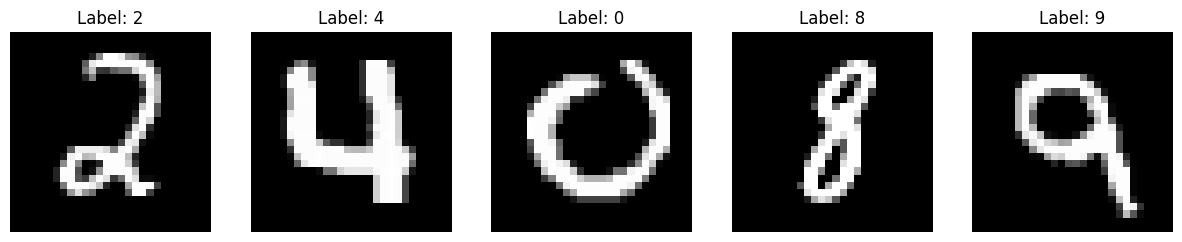

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get 5 random samples from the training dataset
indices = np.random.choice(len(train_dataset), size=5, replace=False)
samples = [train_dataset[i] for i in indices]

# Display the samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (image, label) in enumerate(samples):
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_dataset, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7cea714e2150>, <torch.utils.data.dataloader.DataLoader object at 0x7cea71277010>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [7]:
import torch.nn as nn

class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                       out_channels=hidden_units,
                       kernel_size=3,
                       stride=1,
                       padding=1), # values for kernel_size, stride and padding are from CNN explainer website
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                       out_channels=hidden_units,
                       kernel_size=3,
                       stride=1,
                       padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our inputs data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

# Create an instance of the model with appropriate input/output shapes for MNIST
model_2 = TinyVGG(input_shape=1, hidden_units=10, output_shape=10)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [9]:
# Training on CPU
import torch.optim as optim
import time

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Instantiate model and move it to the CPU
model_2 = TinyVGG(input_shape=1, hidden_units=10, output_shape=10).to("cpu")

# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2.parameters())

print(f"Training on cpu...")
start_time = time.time()

# Training loop for 5 epochs
for epoch in range(5):
    for batch_idx, (X, y) in enumerate(train_dataloader):
        X, y = X.to("cpu"), y.to("cpu")

        # Forward pass
        preds = model_2(X)
        loss = loss_fn(preds, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

end_time = time.time()
print(f"Training time on cpu: {end_time - start_time:.2f} seconds")

Using device: cuda
Training on cpu...
Training time on cpu: 199.66 seconds


In [10]:
# Training on CUDA
import torch.optim as optim
import time

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Instantiate model and move it to the CUDA device if available
if torch.cuda.is_available():
    model_2 = TinyVGG(input_shape=1, hidden_units=10, output_shape=10).to("cuda")

    # Define loss function and optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_2.parameters())

    print(f"Training on cuda...")
    start_time = time.time()

    # Training loop for 5 epochs
    for epoch in range(5):
        for batch_idx, (X, y) in enumerate(train_dataloader):
            X, y = X.to("cuda"), y.to("cuda")

            # Forward pass
            preds = model_2(X)
            loss = loss_fn(preds, y)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    end_time = time.time()
    print(f"Training time on cuda: {end_time - start_time:.2f} seconds")
else:
    print("CUDA is not available. Skipping CUDA training.")

Using device: cuda
Training on cuda...
Training time on cuda: 54.78 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

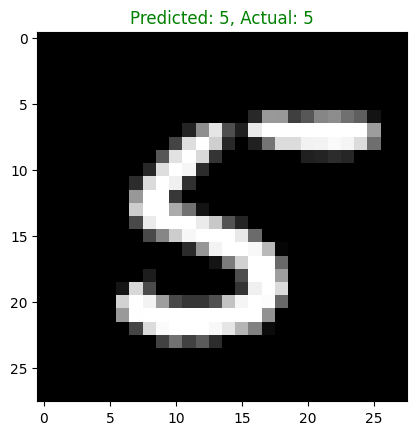

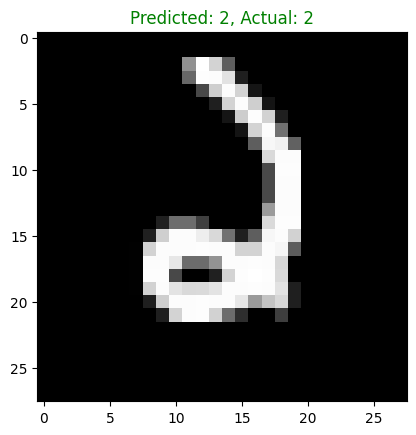

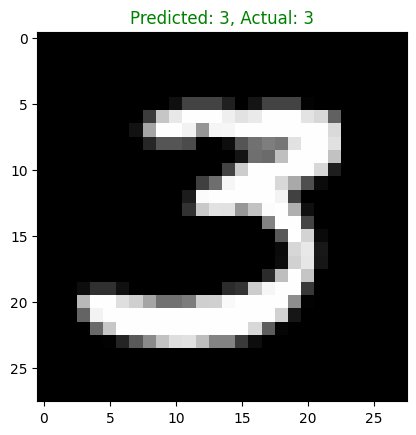

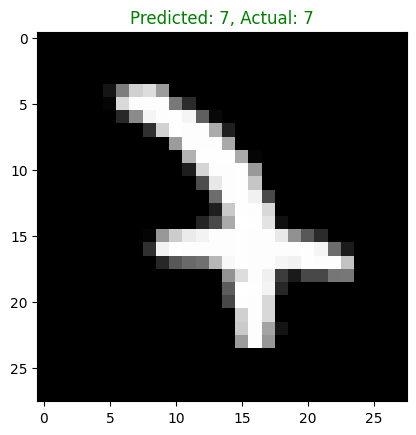

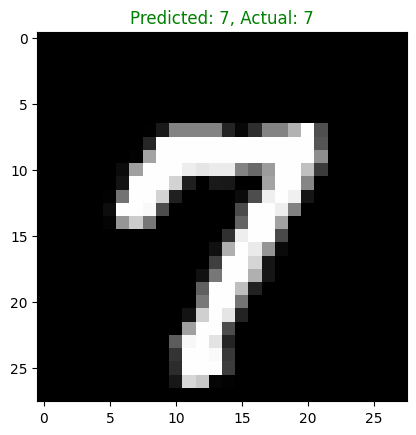

In [11]:
# Make predictions on a few random samples from the test set
import random
import matplotlib.pyplot as plt

model_2.eval()  # Set the model to evaluation mode
with torch.inference_mode():
    for i in range(5):
        # Get a random sample from the test set
        random_index = random.randint(0, len(test_dataset) - 1)
        image, label = test_dataset[random_index]

        # Move the image to the device
        image = image.unsqueeze(0).to(device)  # Add a batch dimension

        # Make a prediction
        pred = model_2(image)
        predicted_label = pred.argmax(dim=1).item()

        # Display the image and prediction with colored title
        plt.imshow(image.cpu().squeeze(), cmap='gray')
        if predicted_label == label:
            # Correct prediction - green title
            plt.title(f"Predicted: {predicted_label}, Actual: {label}", color='green')
        else:
            # Incorrect prediction - red title
            plt.title(f"Predicted: {predicted_label}, Actual: {label}", color='red')
        plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

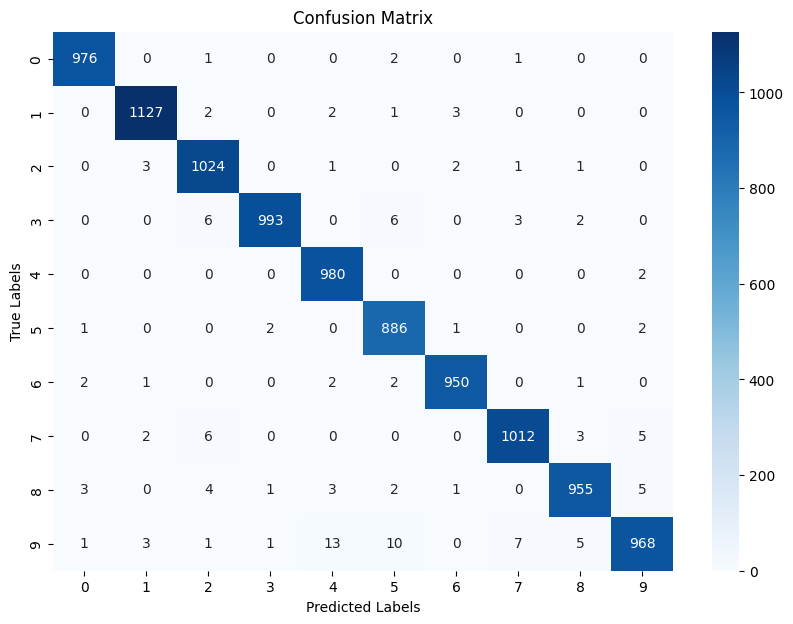

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the entire test set
all_preds = []
all_labels = []
model_2.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        preds = model_2(X)
        all_preds.extend(preds.argmax(dim=1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [13]:
import torch
import torch.nn as nn

# Create a random tensor
random_tensor = torch.randn(1, 3, 64, 64)

# Define a Conv2d layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=0)

# Pass the tensor through the layer with different kernel sizes
for kernel_size in [1, 3, 5, 7]:
    conv_layer.kernel_size = (kernel_size, kernel_size)  # Update kernel size
    output_tensor = conv_layer(random_tensor)
    print(f"Kernel size: {kernel_size}, Output shape: {output_tensor.shape}")

Kernel size: 1, Output shape: torch.Size([1, 16, 62, 62])
Kernel size: 3, Output shape: torch.Size([1, 16, 62, 62])
Kernel size: 5, Output shape: torch.Size([1, 16, 62, 62])
Kernel size: 7, Output shape: torch.Size([1, 16, 62, 62])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

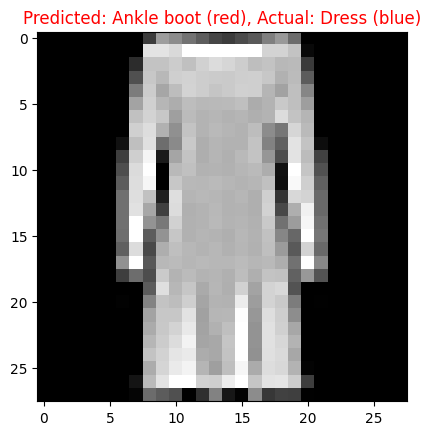

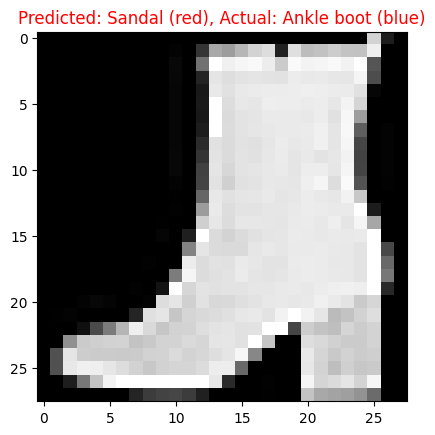

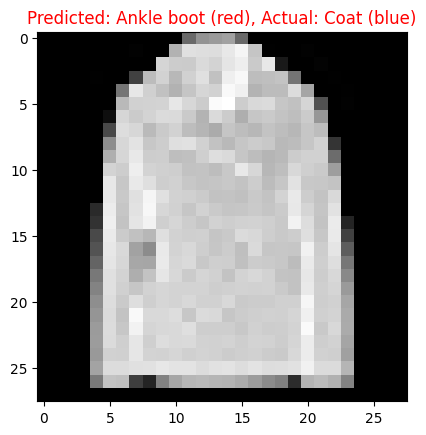

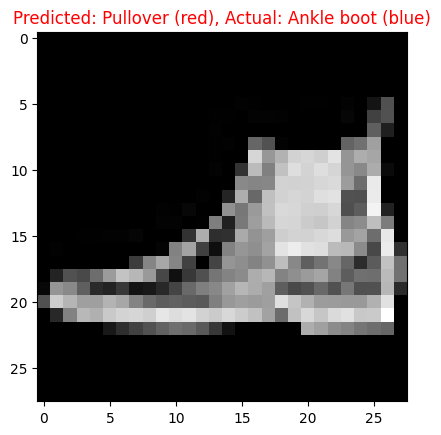

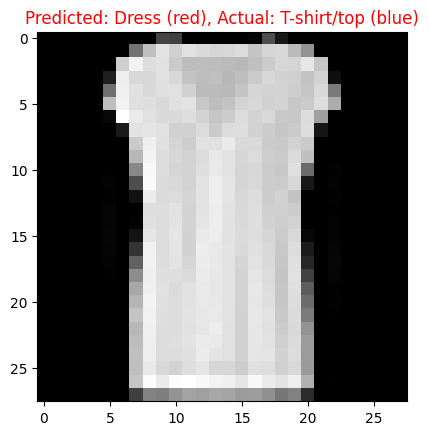

In [15]:
import torchvision
import matplotlib.pyplot as plt
import random

# Load the FashionMNIST dataset
fashion_mnist_test = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# Create a DataLoader for the FashionMNIST test set
fashion_mnist_test_loader = DataLoader(fashion_mnist_test, batch_size=32, shuffle=False)

# Class labels for FashionMNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Get predictions and visualize incorrect ones
incorrect_predictions = []
model_2.eval()  # Set the model to evaluation mode
with torch.inference_mode():
    for images, labels in fashion_mnist_test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model_2(images)
        predicted_labels = preds.argmax(dim=1)

        # Find incorrect predictions
        incorrect_indices = (predicted_labels != labels).nonzero(as_tuple=True)[0]
        for index in incorrect_indices:
            incorrect_predictions.append((images[index], predicted_labels[index], labels[index]))

# Visualize some incorrect predictions
num_to_visualize = 5
for image, predicted_label, actual_label in random.sample(incorrect_predictions, num_to_visualize):
    plt.imshow(image.cpu().squeeze(), cmap='gray')

    # Format the title with colored labels
    title_text = f"Predicted: {class_names[predicted_label.item()]} (red), Actual: {class_names[actual_label.item()]} (blue)"

    # Set title color based on correctness
    if predicted_label.item() == actual_label.item():
        title_color = 'green'  # Correct prediction
    else:
        title_color = 'red'    # Incorrect prediction

    plt.title(title_text, color=title_color)
    plt.show()